Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from langgraph.graph import StateGraph,START,END
from typing import Annotated
from typing import TypedDict
from langgraph.graph.message import add_messages
class state(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(state)

In [2]:
graph_builder

In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
def chatbot(state:state):
    return {"messages":[llm.invoke(state["messages"])]}

In [6]:
graph_builder=StateGraph(state)
graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

#compile the graph
graph=graph_builder.compile()


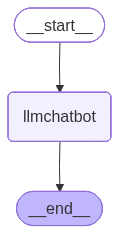

In [7]:
#visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [8]:
response=graph.invoke({"messages":"Hi"})

In [9]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [10]:
for event in graph.stream({"messages":"Hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello. I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?


Chatbot With Tool

In [11]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. * Build the workflow graph using LangGraph, adding nodes for classification and response, connecting them with edges and compiling the app. + [Introduction5 min read](https://www.geeksforgeeks.org/machine-learning/introduction-machine-learning/). + [Types7 min read](https://www.geeksforgeeks.org/machine-learning/types-of-machine-learning/). + [ML Pipeline6 min read](https://ww

In [26]:
#custom function
def multiply(a:int,b:int)->int:
    """multiply a and b
    args:
        a(int):first int
        b(int):second int

    returns
        int:output int
    """
    return a*b

In [27]:
tools=[tool,multiply]

In [28]:
llm_with_tool=llm.bind_tools(tools)

In [29]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000025C2BCE81A0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000025C2BCE8EC0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool del

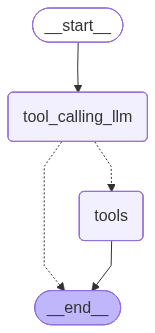

In [30]:
#stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

#node definition
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

#graph
builder=StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
response=graph.invoke({"messages":"what is the recent ai news"})

In [32]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/video/study-evaluates-how-accurate-ai-news-current-events-theres-lot-work-done/", "title": "Study evaluates how accurate AI is on news and current events: \\"There\'s a lot of work to be done\\" - CBS News", "score": 0.70580584, "published_date": "Tue, 26 May 2026 21:34:15 GMT", "content": "Image 101: Kouri Richins: Behind the Facade ### Kouri Richins: Behind the Facade 42:02 May 24, 2026Image 102: The Man with Two Names ### The Man with Two Names 41:32 May 17, 2026Image 103: Joe Hunter\'s Mission ### Joe Hunter\'s Mission 42:09 May 17, 2026Image 104: Beverly Hills 911 ### Beverly Hills 911 42:00 May 10, 2026Image 105: The Love Bombing of Gloria Choi ### The Love Bombing of Gloria Choi 41:42 May 3, 2026Image 106: The Killing of Theresa Fusco ### The Killing of Theresa Fusco 42:02 Apr 26, 2026Image 107: Jade Colvin is Missing ### Jade Colvin is Missing 41:

In [33]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (x7ft6a2cb)
 Call ID: x7ft6a2cb
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/video/study-evaluates-how-accurate-ai-news-current-events-theres-lot-work-done/", "title": "Study evaluates how accurate AI is on news and current events: \"There's a lot of work to be done\" - CBS News", "score": 0.70580584, "published_date": "Tue, 26 May 2026 21:34:15 GMT", "content": "Image 101: Kouri Richins: Behind the Facade ### Kouri Richins: Behind the Facade 42:02 May 24, 2026Image 102: The Man with Two Na

In [34]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (hbj53rh1g)
 Call ID: hbj53rh1g
  Args:
    query: recent ai news
    search_depth: basic
    topic: news
  multiply (vecxjpv6a)
 Call ID: vecxjpv6a
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.tipranks.com/news/private-companies/eightfold-ai-highlights-workforce-transformation-collaboration-with-deloitte", "title": "Eightfold AI Highlights Workforce Transformation Collaboration With Deloitte - TipRanks", "score": 0.6522641, "published_date": "Fri, 29 May 2026 06:05:44 GMT", "content": "# Eightfold AI Highlights Workforce Transformation Collabora

ReAct Agent Architecture

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(state)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))